# Bahraini Currency Classification (CNN - Functional API)

Guided Lab: image classification of Bahraini currency notes (BHD).

Structure follows the same workflow as `03_nn_Functional_API.ipynb`, adapted for real RGB currency images instead of Fashion MNIST.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from PIL import Image
import pillow_heif
import tensorflow as tf

from tensorflow.keras.utils import set_random_seed
from tensorflow.keras.layers import Rescaling
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils import compute_class_weight

import random


seed = 100
random.seed(seed)
np.random.seed(seed)
set_random_seed(seed)

## 2. Loading the Data

Assumes this folder structure (one folder per class, as agreed):

```
data/
  0.5_BHD/
  1_BHD/
  5_BHD/
  10_BHD/
  20_BHD/
  ... (10+ classes)
```

Replace `DATA_DIR` with the path to your `data` folder (e.g. after uploading/mounting it in Colab).

In [2]:
with zipfile.ZipFile("Money (1).zip", 'r') as zip_ref:
    zip_ref.extractall("Moneyy")

In [3]:
for root, dirs, files in os.walk("Moneyy"):
    print(root, "->", len(files), "files", dirs)

Moneyy -> 0 files ['Money']
Moneyy\Money -> 0 files ['Money']
Moneyy\Money\Money -> 0 files ['10BD', '1BD', '20BD', '500 Fils', '5BD']
Moneyy\Money\Money\10BD -> 150 files []
Moneyy\Money\Money\1BD -> 150 files []
Moneyy\Money\Money\20BD -> 281 files []
Moneyy\Money\Money\500 Fils -> 150 files []
Moneyy\Money\Money\5BD -> 150 files []


In [4]:
for root, dirs, files in os.walk("Moneyy/Money/Money"):
    for f in files[:3]:  
        print(os.path.join(root, f))

Moneyy/Money/Money\10BD\10-Back-768x369 - Copy (2).jpg
Moneyy/Money/Money\10BD\10-Back-768x369 - Copy (3).jpg
Moneyy/Money/Money\10BD\10-Back-768x369 - Copy.jpg
Moneyy/Money/Money\1BD\WhatsApp Image 2026-08-09 at 10.49.14 PM (1).jpeg
Moneyy/Money/Money\1BD\WhatsApp Image 2026-08-09 at 10.49.14 PM.jpeg
Moneyy/Money/Money\1BD\WhatsApp Image 2026-08-09 at 10.49.15 PM.jpeg
Moneyy/Money/Money\20BD\18f71b80-d831-4b4f-a3b2-b73d58bdc95e.jpg
Moneyy/Money/Money\20BD\19d70a94-550a-42f4-843d-037ea8eed29e.jpg
Moneyy/Money/Money\20BD\20_0015.jpg
Moneyy/Money/Money\500 Fils\WhatsApp Image 2026-08-09 at 8.18.53 PM.jpeg
Moneyy/Money/Money\500 Fils\WhatsApp Image 2026-08-09 at 8.18.56 PM.jpeg
Moneyy/Money/Money\500 Fils\WhatsApp Image 2026-08-09 at 8.18.59 PM.jpeg
Moneyy/Money/Money\5BD\WhatsApp Image 2026-08-09 at 7.44.26 PM (1).jpeg
Moneyy/Money/Money\5BD\WhatsApp Image 2026-08-09 at 7.44.26 PM (2).jpeg
Moneyy/Money/Money\5BD\WhatsApp Image 2026-08-09 at 7.44.26 PM.jpeg


In [5]:
!pip install pillow-heif


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pillow_heif.register_heif_opener()  

DATA_ROOT = "Moneyy/Money/Money"

ALLOWED_FORMATS = {"JPEG", "PNG", "GIF", "BMP", "WEBP"}

JUNK_NAMES = {"thumbs.db", "desktop.ini", ".ds_store"}

converted = 0
removed_junk = 0
removed_corrupt = 0
kept = 0
bad_report = []

for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        path = os.path.join(root, f)
        lower = f.lower()

        if lower in JUNK_NAMES or "zone.identifier" in lower:
            os.remove(path)
            removed_junk += 1
            continue

        try:
            with Image.open(path) as img:
                fmt = img.format
                img.load()  

            if fmt in ALLOWED_FORMATS:
                kept += 1
                continue

            with Image.open(path) as img:
                rgb_img = img.convert("RGB")
                new_path = os.path.splitext(path)[0] + ".jpg"
                rgb_img.save(new_path, "JPEG")
            if new_path != path:
                os.remove(path)
            converted += 1

        except Exception as e:
            bad_report.append((path, str(e)))
            os.remove(path)
            removed_corrupt += 1

print("✅ صور سليمة من الأصل:", kept)
print("🔄 صور تم تحويلها لـ JPEG:", converted)
print("🗑️ ملفات نظام/زائدة محذوفة:", removed_junk)
print("🗑️ ملفات تالفة/غير صالحة محذوفة:", removed_corrupt)

if bad_report:
    print("\nتفاصيل الملفات التالفة (أول 20):")
    for p, err in bad_report[:20]:
        print(p, "->", err)


✅ صور سليمة من الأصل: 748
🔄 صور تم تحويلها لـ JPEG: 133
🗑️ ملفات نظام/زائدة محذوفة: 0
🗑️ ملفات تالفة/غير صالحة محذوفة: 0


In [7]:
DATA_DIR = "Moneyy/Money/Money"  
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(DATA_DIR,validation_split=0.2,subset="training",seed=seed,image_size=IMG_SIZE,batch_size=BATCH_SIZE,)

val_ds = tf.keras.utils.image_dataset_from_directory(DATA_DIR,validation_split=0.2,subset="validation",seed=seed,image_size=IMG_SIZE,batch_size=BATCH_SIZE,)

class_names = train_ds.class_names

num_classes = len(class_names)

print(class_names)

Found 748 files belonging to 5 classes.
Using 599 files for training.
Found 748 files belonging to 5 classes.
Using 149 files for validation.
['10BD', '1BD', '20BD', '500 Fils', '5BD']


### Quick look at the data

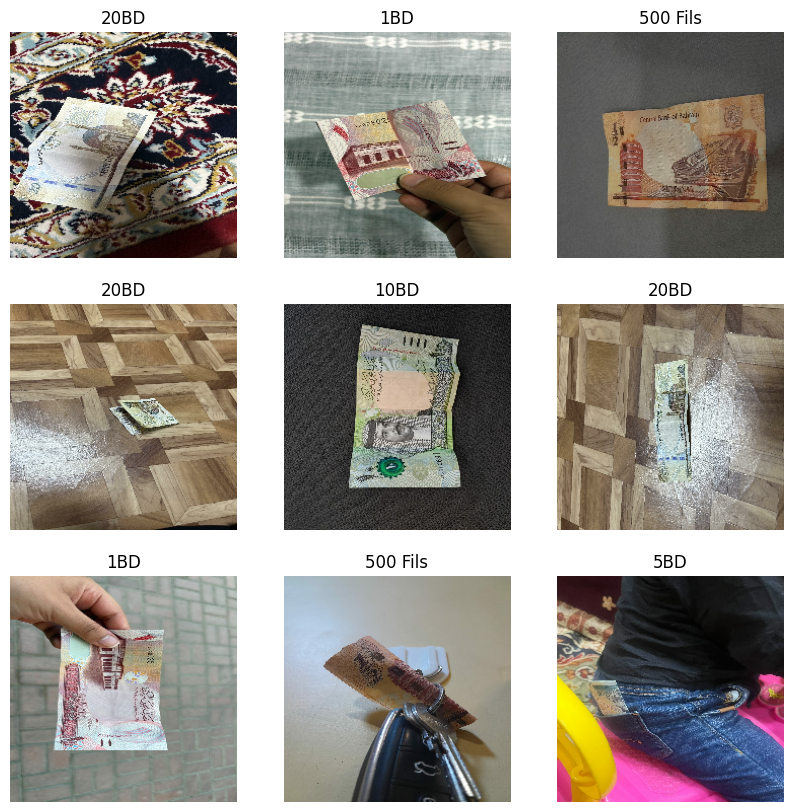

In [8]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
        
plt.show()

## 3. Preprocessing

- Resizing: already done by `image_dataset_from_directory` (224x224)
- Normalization: `Rescaling(1./255)` inside the model
- Data augmentation: rotation, zoom, horizontal flip, brightness (train set only)

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [10]:
inputs = Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = Rescaling(1./255)(x)

x = Conv2D(32, 3, activation="relu")(x)
x = MaxPooling2D()(x)

x = Conv2D(64, 3, activation="relu")(x)
x = MaxPooling2D()(x)

x = Conv2D(128, 3, activation="relu")(x)
x = MaxPooling2D()(x)

x = Flatten()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

outputs = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Modeling using Functional API

CNN instead of flattening the raw image directly (images are RGB 224x224x3, not simple 28x28 grayscale).

## 5. Compile & Train

In [11]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"],)

es = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(train_ds,validation_data=val_ds,epochs=50,callbacks=[es],)

Epoch 1/50


C:\Users\user\PycharmProjects\PythonProject\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


19/19 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.2020 - loss: 2.2729 - val_accuracy: 0.2148 - val_loss: 1.6069
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.2671 - loss: 1.5901 - val_accuracy: 0.4027 - val_loss: 1.4906
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.3205 - loss: 1.5178 - val_accuracy: 0.4094 - val_loss: 1.4060
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.3957 - loss: 1.4423 - val_accuracy: 0.3356 - val_loss: 1.4017
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.4457 - loss: 1.3448 - val_accuracy: 0.6040 - val_loss: 1.1404
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.5476 - loss: 1.1506 - val_accuracy: 0.6242 - val_loss: 1.0020
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.5676 - loss: 1.0737 - val_accuracy: 0.6913 - val_loss: 0.9379
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.5993 - loss: 1.0085 - val_accuracy: 0.7114 - val_loss: 0.8582
Epo

## 6. Training History

<Axes: title={'center': 'Loss'}>

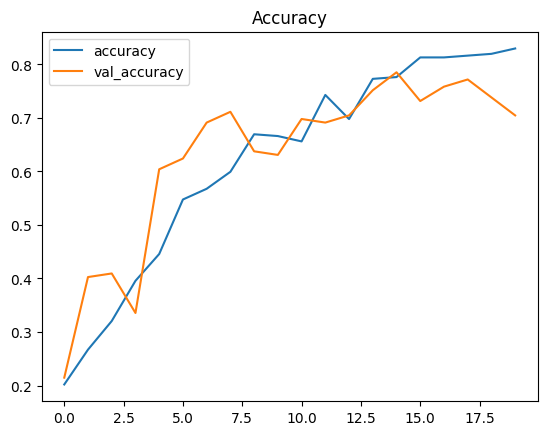

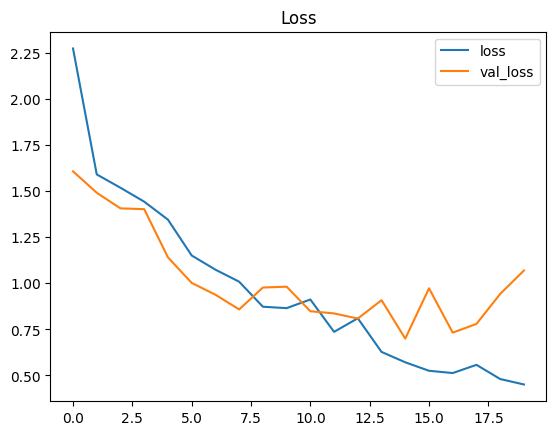

In [12]:
history_df = pd.DataFrame(history.history)

history_df[['accuracy', 'val_accuracy']].plot(title="Accuracy")

history_df[['loss', 'val_loss']].plot(title="Loss")

### (Optional) Class Weights
Use this only if the dataset turns out imbalanced across currency classes (check the counts above).

In [13]:
y_train_labels = np.array([y.numpy() for _, y in train_ds.unbatch()])

class_weights = compute_class_weight(class_weight="balanced",classes=np.unique(y_train_labels),y=y_train_labels,)

class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(1.0417391304347825),
 1: np.float64(1.0067226890756302),
 2: np.float64(1.0067226890756302),
 3: np.float64(0.9819672131147541),
 4: np.float64(0.9661290322580646)}

## 7. Evaluation

Accuracy, confusion matrix, precision/recall, per-class performance.

In [14]:
y_true = np.array([y.numpy() for _, y in val_ds.unbatch()])

y_pred_probs = model.predict(val_ds)

y_pred = np.argmax(y_pred_probs, axis=1)

print("Accuracy:", accuracy_score(y_true, y_pred))

print(classification_report(y_true, y_pred, target_names=class_names))

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 278ms/step
Accuracy: 0.785234899328859
              precision    recall  f1-score   support

        10BD       0.81      0.88      0.84        33
         1BD       0.74      0.81      0.77        31
        20BD       0.84      0.87      0.86        31
    500 Fils       0.89      0.61      0.72        28
         5BD       0.68      0.73      0.70        26

    accuracy                           0.79       149
   macro avg       0.79      0.78      0.78       149
weighted avg       0.79      0.79      0.78       149



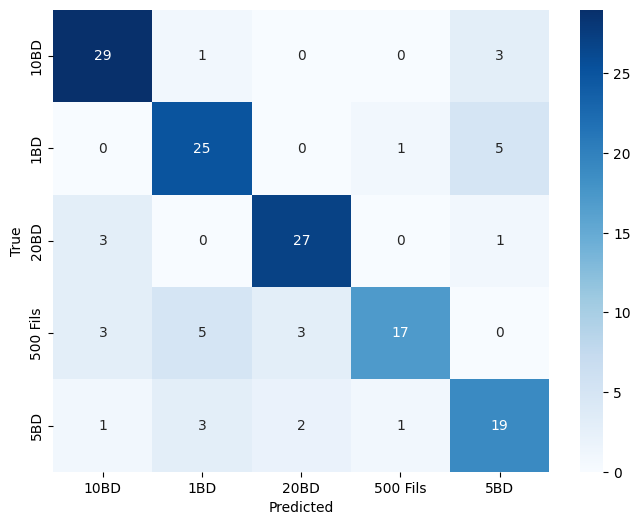

In [15]:
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="g",xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.show()

## 8. Error Analysis

Look at misclassified images — which currency notes get confused with each other?

32 misclassified out of 149


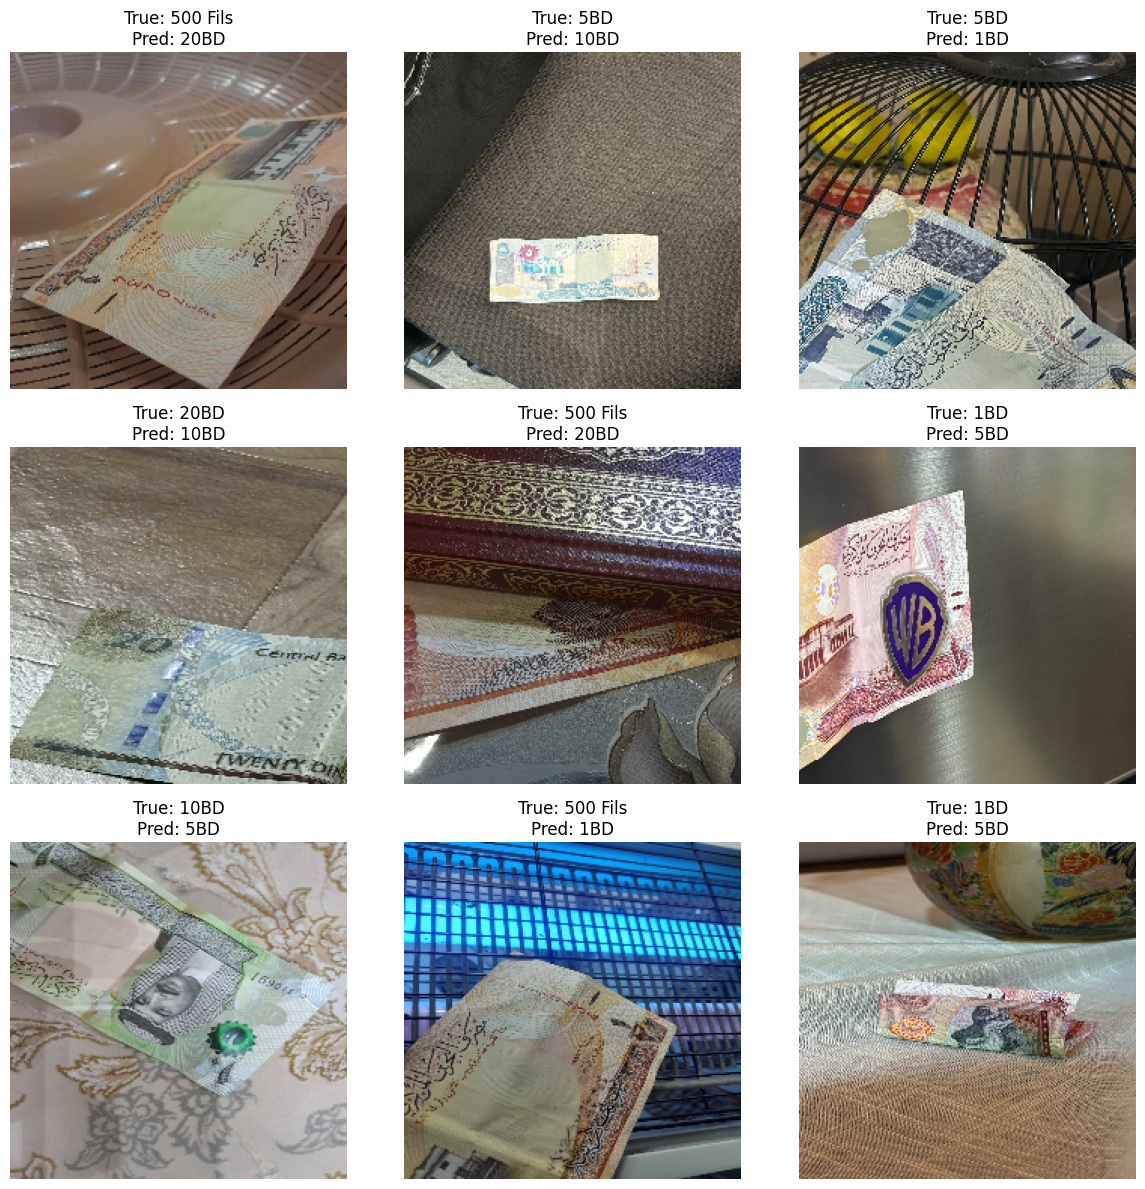

In [17]:
val_images = np.stack([x.numpy() for x, _ in val_ds.unbatch()])

wrong_idx = np.where(y_true != y_pred)[0]

print(f"{len(wrong_idx)} misclassified out of {len(y_true)}")

plt.figure(figsize=(12, 12))

for i, idx in enumerate(wrong_idx[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(val_images[idx].astype("uint8"))
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis("off")
    
plt.tight_layout()

plt.show()

## 9. Save the Model

Needed for the Streamlit deployment step (real-world testing).

In [18]:
model.save("bahraini_currency_model.keras")

In [22]:
model.save('bahraini_currency_model.keras', include_optimizer=False)

size_mb = os.path.getsize('bahraini_currency_model.keras') / (1024 * 1024)

print(f'Keras model size: {size_mb:.2f} MB')

Keras model size: 127.89 MB


In [24]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]  

tflite_model = converter.convert()

with open('bahraini_currency_model.tflite', 'wb') as f:
    f.write(tflite_model)

tflite_size_mb = os.path.getsize('bahraini_currency_model.tflite') / (1024 * 1024)

print(f'TFLite model size: {tflite_size_mb:.2f} MB')

INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpcl3y76sy\assets


INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpcl3y76sy\assets


Saved artifact at 'C:\Users\user\AppData\Local\Temp\tmpcl3y76sy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2904239671440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2904239675856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2904239673168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2904239677584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2904239683344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2904239677776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2904230246736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2904230240976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2904198657424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2904230102608: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite m